# SIMPLE NETWORK 2 CON RELU, ADAMW Y TRATADO DE DATOS

Importamos las librerías

In [1]:
# === IMPORTS ===
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
import kagglehub
from torchsummary import summary
import torch.nn.functional as F
import csv
from tqdm import tqdm

c:\Users\ivanp\anaconda3\envs\FSI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Como tenemos una carpeta con las imágenes y otra con las etiquetas (YOLO) lo primero que debemos hacer es modificar este formato para tener un fichero csv con las etiquetas.

In [2]:
# === FRAGMENTO 1 ===
# --- Descarga y Configuración ---
KAGGLE_DATASET_ID = 'pkdarabi/cardetection'
print(f"Descargando dataset: {KAGGLE_DATASET_ID}")
KAGGLE_DOWNLOAD_PATH = kagglehub.dataset_download(KAGGLE_DATASET_ID)

base_data_path = os.path.join(KAGGLE_DOWNLOAD_PATH, "car")
splits_names = ["train", "valid", "test"]
DATA_DIR = '../' 
CSV_DIR = os.path.join(DATA_DIR, "CSVs")
os.makedirs(CSV_DIR, exist_ok=True)

print("\n--- Generando CSVs ---")
csv_header = ['nombre_archivo', 'clase_indice', 'x_center', 'y_center', 'width', 'height']

for split in splits_names:
    labels_dir = os.path.join(base_data_path, split, "labels")
    output_csv_file = os.path.join(CSV_DIR, f"labels_{split}.csv")
    
    if not os.path.exists(labels_dir): continue

    with open(output_csv_file, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(csv_header)
        for txt_filename in os.listdir(labels_dir):
            if txt_filename.endswith('.txt'):
                image_filename = txt_filename.replace('.txt', '.jpg')
                txt_filepath = os.path.join(labels_dir, txt_filename)
                try:
                    with open(txt_filepath, 'r') as f_txt:
                        for line in f_txt:
                            parts = line.strip().split()
                            if len(parts) == 5:
                                writer.writerow([image_filename] + parts)
                except: pass
    print(f"CSV Creado: {output_csv_file}")

IMAGE_SIZE = (416, 416) 

# Normalización estándar (0.5) para redes desde cero
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# --- TRANSFORMACIÓN DE VALIDACIÓN (SIN AUMENTACIÓN) ---
# La validación debe ser limpia, tal cual son las imágenes reales.
val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

class DataSet(Dataset):
    def __init__(self, archivo_csv, directorio_imagenes, transform=None):
        self.directorio_imagenes = directorio_imagenes
        self.transform = transform
        if os.path.exists(archivo_csv):
            self.full_labels_df = pd.read_csv(archivo_csv)
        else:
            self.full_labels_df = pd.DataFrame(columns=['nombre_archivo', 'clase_indice'])
        self.imagenes_unicas = self.full_labels_df['nombre_archivo'].unique()
        self.labels_grouped = self.full_labels_df.groupby('nombre_archivo')

    def __len__(self):
        return len(self.imagenes_unicas)

    def __getitem__(self, idx):
        image_name = self.imagenes_unicas[idx]
        image_path = os.path.join(self.directorio_imagenes, image_name)
        
        try:
            image = Image.open(image_path).convert('RGB')
        except:
            # Si falla la carga, devolvemos un tensor negro para no romper el flujo
            # Nota: transformamos a tensor manualmente aquí si falla
            return torch.zeros(3, IMAGE_SIZE[0], IMAGE_SIZE[1]), torch.tensor(0)

        boxes_df = self.labels_grouped.get_group(image_name)
        clase_idx = int(boxes_df['clase_indice'].iloc[0])
        
        # --- APLICAR TRANSFORMACIÓN ---
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(clase_idx, dtype=torch.long)

Descargando dataset: pkdarabi/cardetection

--- Generando CSVs ---
CSV Creado: ../CSVs\labels_train.csv
CSV Creado: ../CSVs\labels_valid.csv
CSV Creado: ../CSVs\labels_test.csv


In [3]:
# === FRAGMENTO 2 ===
# Preparación de los CSVs corregidos
def procesar_csv(archivo_entrada, archivo_salida):
    print(f"\n--- Iniciando procesamiento de: '{archivo_entrada}' ---")
    
    filas_eliminadas = 0
    filas_modificadas = 0
    filas_totales_escritas = 0

    try:
        with open(archivo_entrada, mode='r', newline='') as infile, \
             open(archivo_salida, mode='w', newline='') as outfile:

            reader = csv.reader(infile)
            writer = csv.writer(outfile)

            try:
                header = next(reader)
                writer.writerow(header)
            except StopIteration:
                print(f"Error: El archivo '{archivo_entrada}' está vacío.")
                return

            for row in reader:
                if not row:
                    continue

                try:
                    clase_index = int(row[1])
                    
                    if clase_index == 2:
                        filas_eliminadas += 1
                        continue

                    elif clase_index > 2:
                        clase_index -= 1
                        filas_modificadas += 1
                        row[1] = str(clase_index)
                    
                    writer.writerow(row)
                    filas_totales_escritas += 1

                except ValueError:
                    print(f"Advertencia: Se omitió una fila mal formada (índice no numérico): {row}")
                except IndexError:
                    print(f"Advertencia: Se omitió una fila mal formada (faltan columnas): {row}")

        print(f"Resultados guardados en: '{archivo_salida}'")
        print(f"Filas eliminadas: {filas_eliminadas}")
        print(f"Filas re-mapeadas: {filas_modificadas}")
        print(f"Total de filas escritas: {filas_totales_escritas}")

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo de entrada '{archivo_entrada}'.")
    except Exception as e:
        print(f"Ocurrió un error inesperado con '{archivo_entrada}': {e}")

archivos_a_procesar = [
    ('../CSVs/labels_train.csv', '../CSVs/train_corregido.csv'),
    ('../CSVs/labels_valid.csv', '../CSVs/valid_corregido.csv'),
    ('../CSVs/labels_test.csv', '../CSVs/test_corregido.csv')
]
print("Iniciando el procesamiento de todos los archivos...")

for entrada, salida in archivos_a_procesar:
    procesar_csv(entrada, salida)

print("\n--- ¡Proceso de todos los archivos completado! ---")

Iniciando el procesamiento de todos los archivos...

--- Iniciando procesamiento de: '../CSVs/labels_train.csv' ---
Resultados guardados en: '../CSVs/train_corregido.csv'
Filas eliminadas: 19
Filas re-mapeadas: 3152
Total de filas escritas: 4279

--- Iniciando procesamiento de: '../CSVs/labels_valid.csv' ---
Resultados guardados en: '../CSVs/valid_corregido.csv'
Filas eliminadas: 0
Filas re-mapeadas: 714
Total de filas escritas: 944

--- Iniciando procesamiento de: '../CSVs/labels_test.csv' ---
Resultados guardados en: '../CSVs/test_corregido.csv'
Filas eliminadas: 3
Filas re-mapeadas: 563
Total de filas escritas: 767

--- ¡Proceso de todos los archivos completado! ---


Ahora ya podemos crear una instancia de la clase Dataset

In [4]:
# === FRAGMENTO 3 ===
print("\n--- Cargando Datasets y DataLoaders desde los CSVs generados ---")

datasets = {}
dataloaders = {}
BATCH_SIZE = 32
 
for label in splits_names:
    # Construir rutas
    ruta_csv = os.path.join(DATA_DIR, f"CSVs/{label}_corregido.csv") 
    ruta_imgs = os.path.join(base_data_path, label, "images")
    
    print(f"\nProcesando conjunto de datos: {label}")
    print(f"Ruta del CSV: {ruta_csv}")
    print(f"Ruta de las imágenes: {ruta_imgs}")

    if not os.path.exists(ruta_csv) or not os.path.exists(ruta_imgs):
        print("  - Error: No se encontró el CSV o el directorio de imágenes.")

    else:
        # Asignar la transformación correcta según el split
        if label == 'train':
            transform_actual = train_transform
        else:
            transform_actual = val_transform
            
        # Crear el Dataset
        dataset = DataSet(archivo_csv=ruta_csv, 
                          directorio_imagenes=ruta_imgs, 
                          transform=transform_actual)
        
        if len(dataset) > 0:
            print(f"  - Tipo de objeto creado: {type(dataset)}")
            print(f"  - Número total de imágenes: {len(dataset)}")

            datasets[label] = dataset
            
            # --- OPTIMIZACIÓN DE GPU ---
            dataloaders[label] = DataLoader(
                dataset,
                batch_size=BATCH_SIZE,
                shuffle=(label == 'train'),
                pin_memory=True,            # Acelera la transferencia a GPU
            )
            print(f"  - DataLoader para '{label}' creado (OPTIMIZADO).")

        else:
            print("  - Error: El dataset está vacío (CSV vacío o no se pudo leer).")

print("\n--- Proceso de carga completado ---")


--- Cargando Datasets y DataLoaders desde los CSVs generados ---

Procesando conjunto de datos: train
Ruta del CSV: ../CSVs/train_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\train\images
  - Tipo de objeto creado: <class '__main__.DataSet'>
  - Número total de imágenes: 3518
  - DataLoader para 'train' creado (OPTIMIZADO).

Procesando conjunto de datos: valid
Ruta del CSV: ../CSVs/valid_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\valid\images
  - Tipo de objeto creado: <class '__main__.DataSet'>
  - Número total de imágenes: 801
  - DataLoader para 'valid' creado (OPTIMIZADO).

Procesando conjunto de datos: test
Ruta del CSV: ../CSVs/test_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\test\images
  - Tipo de objeto creado: <class '__main__.DataSet'>
  - Número total de imágenes: 63

A continuación creamos la red neuronal que entrenaremos con el dataset que hemos creado. SIGMOIDE

In [5]:
# === FRAGMENTO 4 ===
class SimpleNN(nn.Module):
    def __init__(self, num_classes=14):
        super(SimpleNN, self).__init__()
        
        # Cálculo automático del tamaño aplanado
        self.flatten_size = 3 * 416 * 416 
        
        # Arquitectura Piramidal (Reduciendo progresivamente)
        self.fc1 = nn.Linear(self.flatten_size, 512)    # Bajar a 128 para controlar entrada
        self.bn1 = nn.BatchNorm1d(512)
        
        self.fc2 = nn.Linear(512, 256)                  # Cuello de botella invertido (ayuda a mezclar features)
        self.bn2 = nn.BatchNorm1d(256)
        
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        
        self.out = nn.Linear(64, num_classes)
        
        self.dropout = nn.Dropout(0.5) # Dropout para evitar memorización

    def forward(self, x):
        # Aplanar
        x = x.view(x.size(0), -1) 
        
        # Capa 1
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        
        # Capa 2
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        
        # Capa 3
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)

        # Capa 4
        x = F.relu(self.bn4(self.fc4(x)))
        
        # Salida
        x = self.out(x)
        return x

def create_simple_model(num_classes=14):
    model = SimpleNN(num_classes=num_classes)
    print(f"Modelo SimpleNN (416x416) creado.")
    print(f"Neuronas de entrada: {model.flatten_size}")
    return model

Definimos la función de perdida y el optimizador.

In [6]:
# === FRAGMENTO 5 ===
# 1. Definir el dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

msg = f"GPU: {torch.cuda.get_device_name(0)}" if device.type == 'cuda' else "CPU"
print(f"\n--- Usando {msg} ---\n")

# 2. Mover el modelo al dispositivo
model = SimpleNN().to(device) 

# 3. Llamar al summary (automáticamente usará el dispositivo correcto)
# Actualizar el input_size del summary a 416
try:
    summary(model, (3, 416, 416))
except Exception as e:
    print(f"Error en summary (probablemente por memoria): {e}")
    # Si summary falla por memoria, no detiene el entrenamiento, solo es informativo.


--- Usando GPU: NVIDIA GeForce RTX 3060 Ti ---

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]     265,814,528
       BatchNorm1d-2                  [-1, 512]           1,024
           Dropout-3                  [-1, 512]               0
            Linear-4                  [-1, 256]         131,328
       BatchNorm1d-5                  [-1, 256]             512
           Dropout-6                  [-1, 256]               0
            Linear-7                  [-1, 128]          32,896
       BatchNorm1d-8                  [-1, 128]             256
           Dropout-9                  [-1, 128]               0
           Linear-10                   [-1, 64]           8,256
      BatchNorm1d-11                   [-1, 64]             128
           Linear-12                   [-1, 14]             910
Total params: 265,989,838
Trainable params: 265,989,83

Ahora ya podemos entrenar la red.

In [7]:
# === FRAGMENTO 6 ===
print("--- Configuración Inicial ---")

# Verificar GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# Hiperparámetros
IMAGE_SIZE = (416, 416)  # Tamaño para Red Simple (MLP)
BATCH_SIZE = 32          # Aumentado para aprovechar la 3060 Ti
NUM_CLASSES = 14         # Clases del dataset (0 a 13)
EPOCHS = 50
LEARNING_RATE = 0.001
CSV_HISTORY_FILE = 'results/training_history_simple2.csv'
EARLY_STOP_PATIENCE = 10
WEIGHT_DECAY = 1e-4      # Regularización L2 para AdamW

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)  # Optimizador AdamW
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)

history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
epochs_no_improve = 0
min_delta = 0.001

print(f"\n--- Iniciando Entrenamiento ({EPOCHS} épocas) ---")
print(f"Datos guardados en: {CSV_HISTORY_FILE}")

for epoch in range(EPOCHS):
    current_epoch = epoch + 1
    
    # --- TRAIN ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    train_loop = tqdm(dataloaders['train'], desc=f"Epoch {current_epoch}/{EPOCHS}", leave=False)
    
    for images, labels in train_loop:
        if -1 in labels: continue
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # 3. Gradient Clipping: Estabiliza los gradientes en redes grandes
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item())

    # --- VALID ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloaders['valid']:
            if -1 in labels: continue
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    # --- METRICS ---
    avg_train_loss = train_loss / len(dataloaders['train'])
    avg_train_acc = (correct_train / total_train) * 100
    avg_val_loss = val_loss / len(dataloaders['valid'])
    avg_val_acc = (correct_val / total_val) * 100
    
    # --- LOGGING ---
    history['epoch'].append(current_epoch)
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    print(f"Epoch {current_epoch} | T.Loss: {avg_train_loss:.4f} T.Acc: {avg_train_acc:.2f}% | V.Loss: {avg_val_loss:.4f} V.Acc: {avg_val_acc:.2f}%")
    
    scheduler.step(avg_val_acc)
    pd.DataFrame(history).to_csv(CSV_HISTORY_FILE, index=False)

    # --- EARLY STOPPING & CHECKPOINT ---
    if avg_val_acc > (best_val_acc + min_delta):
        print(f" -> ¡Mejora! ({best_val_acc:.2f}% -> {avg_val_acc:.2f}%) Guardando modelo...")
        best_val_acc = avg_val_acc
        torch.save(model.state_dict(), 'results/best_simple_model2.pth')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print("\n--- ¡Early Stopping activado! ---")
        break

print(f"\nEntrenamiento finalizado. Mejor Precisión: {best_val_acc:.2f}%")

--- Configuración Inicial ---
Usando dispositivo: NVIDIA GeForce RTX 3060 Ti

--- Iniciando Entrenamiento (50 épocas) ---
Datos guardados en: results/training_history_simple2.csv


Epoch 1 | T.Loss: 2.5924 T.Acc: 12.02% | V.Loss: 2.4751 V.Acc: 19.60%
 -> ¡Mejora! (0.00% -> 19.60%) Guardando modelo...


Epoch 2 | T.Loss: 2.4650 T.Acc: 18.53% | V.Loss: 2.3009 V.Acc: 26.09%
 -> ¡Mejora! (19.60% -> 26.09%) Guardando modelo...


Epoch 3 | T.Loss: 2.3635 T.Acc: 24.02% | V.Loss: 2.2258 V.Acc: 27.34%
 -> ¡Mejora! (26.09% -> 27.34%) Guardando modelo...


Epoch 4 | T.Loss: 2.3033 T.Acc: 25.84% | V.Loss: 2.1992 V.Acc: 29.71%
 -> ¡Mejora! (27.34% -> 29.71%) Guardando modelo...


...

Epoch 46 | T.Loss: 1.9523 T.Acc: 40.62% | V.Loss: 1.8858 V.Acc: 45.44%


Epoch 47 | T.Loss: 1.9406 T.Acc: 40.82% | V.Loss: 1.8886 V.Acc: 45.19%


Epoch 48 | T.Loss: 1.9639 T.Acc: 40.85% | V.Loss: 1.8891 V.Acc: 45.94%


Epoch 49 | T.Loss: 1.9483 T.Acc: 40.59% | V.Loss: 1.8859 V.Acc: 45.69%


Epoch 50 | T.Loss: 1.9500 T.Acc: 41.16% | V.Loss: 1.8832 V.Acc: 45.32%

--- ¡Early Stopping activado! ---

Entrenamiento finalizado. Mejor Precisión: 46.69%


Y por último evaluamos la red.

Datos cargados: 50 épocas encontradas.
Gráfica guardada en: results/grafica_loss_simple2.png


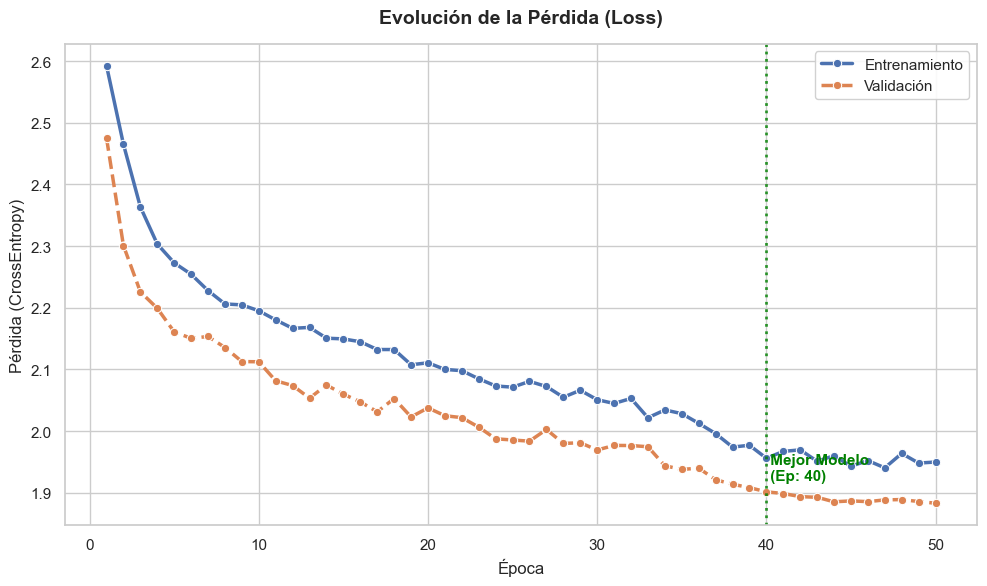

Gráfica guardada en: results/grafica_accuracy_simple2.png


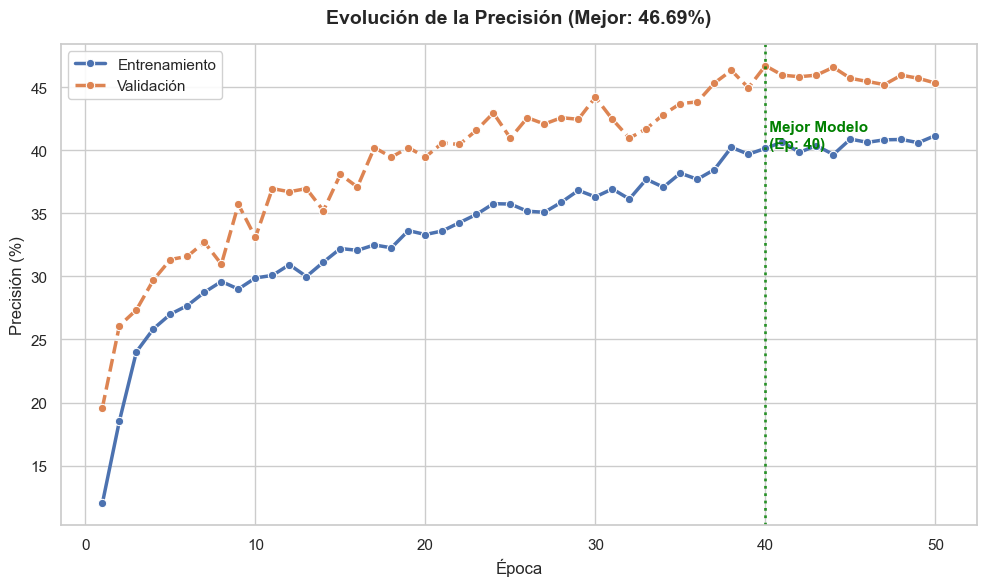

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === CONFIGURACIÓN ===
# Asegúrate de que este nombre coincida con el que definiste en el entrenamiento
CSV_FILE = 'results/training_history_simple2.csv' 
SAVE_DIR = 'results/' 

# 1. Cargar datos
if not os.path.exists(CSV_FILE):
    print(f"Error: No se encuentra el archivo '{CSV_FILE}'.")
else:
    df = pd.read_csv(CSV_FILE)
    print(f"Datos cargados: {len(df)} épocas encontradas.")

    # 2. Configurar estilo (Seaborn)
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 11})

    # 3. Encontrar la MEJOR época (Basado en Validation Accuracy)
    # Esto marca el punto donde se guardó el 'best_simple_model.pth'
    best_epoch_idx = df['val_acc'].idxmax()
    best_epoch_val = df.iloc[best_epoch_idx]['epoch']
    best_acc_val = df.iloc[best_epoch_idx]['val_acc']

    # --- FUNCIÓN PARA DIBUJAR ---
    def plot_metric(metric_name, train_col, val_col, title, ylabel, filename):
        plt.figure(figsize=(10, 6))
        
        # Dibujar líneas principales
        sns.lineplot(data=df, x='epoch', y=train_col, label='Entrenamiento', linewidth=2.5, marker='o')
        sns.lineplot(data=df, x='epoch', y=val_col, label='Validación', linewidth=2.5, marker='o', linestyle='--')
        
        # Marcar la mejor época (Best Model Saved)
        plt.axvline(x=best_epoch_val, color='green', linestyle=':', linewidth=2, alpha=0.8)
        
        # Añadir etiqueta en la línea vertical
        y_pos = df[train_col].max() if metric_name == 'Accuracy' else df[train_col].min()
        plt.text(best_epoch_val, y_pos, f' Mejor Modelo\n (Ep: {int(best_epoch_val)})', 
                 color='green', fontweight='bold', ha='left', va='center')

        plt.title(title, fontsize=14, pad=15, fontweight='bold')
        plt.xlabel('Época', fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.legend(loc='best', frameon=True, facecolor='white', framealpha=0.9)
        plt.tight_layout()
        
        # Guardar
        save_path = os.path.join(SAVE_DIR, filename)
        plt.savefig(save_path, dpi=300)
        print(f"Gráfica guardada en: {save_path}")
        plt.show()

    # --- GENERAR GRÁFICAS ---

    # 1. Gráfica de PÉRDIDA (Loss)
    plot_metric(
        metric_name='Loss',
        train_col='train_loss',
        val_col='val_loss',
        title='Evolución de la Pérdida (Loss)',
        ylabel='Pérdida (CrossEntropy)',
        filename='grafica_loss_simple2.png'
    )

    # 2. Gráfica de PRECISIÓN (Accuracy)
    plot_metric(
        metric_name='Accuracy',
        train_col='train_acc',
        val_col='val_acc',
        title=f'Evolución de la Precisión (Mejor: {best_acc_val:.2f}%)',
        ylabel='Precisión (%)',
        filename='grafica_accuracy_simple2.png'
    )

C:\Users\ivanp\AppData\Local\Temp\ipykernel_16116\1343864723.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ruta_modelo, map_location=

✅ Pesos de 'results/best_simple_model2.pth' cargados exitosamente.
Evaluando usando el conjunto de: test
Generando predicciones (esto puede tardar un poco)...

 RESULTADOS DE LA EVALUACIÓN
              precision    recall  f1-score   support

           0       0.45      0.48      0.46        69
           1       0.40      0.57      0.47        56
           2       0.39      0.34      0.36        41
           3       0.00      0.00      0.00        20
           4       0.46      0.31      0.37        35
           5       0.74      0.96      0.83        45
           6       0.35      0.46      0.40        56
           7       0.21      0.23      0.22        47
           8       0.45      0.20      0.28        45
           9       0.51      0.42      0.46        43
          10       0.59      0.55      0.57        47
          11       0.22      0.40      0.28        55
          12       0.00      0.00      0.00        30
          13       0.87      0.70      0.78        47


c:\Users\ivanp\anaconda3\envs\FSI\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ivanp\anaconda3\envs\FSI\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ivanp\anaconda3\envs\FSI\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Matriz de confusión guardada como: results/matriz_confusion_simple2.png


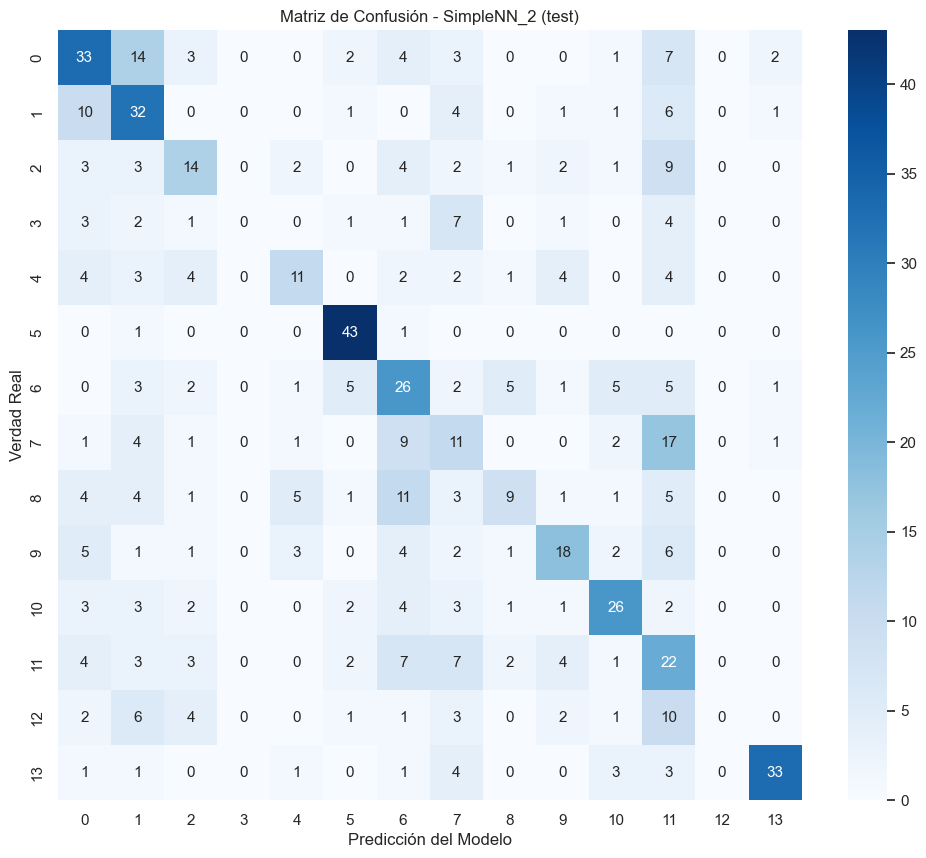

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

# 1. Configuración inicial
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- CAMBIO IMPORTANTE: Instanciar la clase correcta ---
model = SimpleNN(num_classes=14) 

# 2. Cargar los pesos aprendidos
# --- CAMBIO IMPORTANTE: Nombre del archivo correcto ---
ruta_modelo = 'results/best_simple_model2.pth'

if os.path.exists(ruta_modelo):
    try:
        model.load_state_dict(torch.load(ruta_modelo, map_location=device))
        print(f"✅ Pesos de '{ruta_modelo}' cargados exitosamente.")
    except RuntimeError as e:
        print(f"❌ Error de compatibilidad: {e}")
        print("Asegúrate de que la clase SimpleNN tenga el mismo IMAGE_SIZE (416) con el que se entrenó.")
        raise
else:
    print(f"❌ Error: No encuentro '{ruta_modelo}'. Asegúrate de haber completado el entrenamiento.")

model = model.to(device)
model.eval() # IMPORTANTE: Poner en modo evaluación (apaga Dropout)

# 3. Elegir qué datos usar para la prueba
# Intentamos usar 'test', si no existe (porque no procesamos ese CSV), usamos 'valid'
if 'test' in dataloaders:
    nombre_split = 'test'
else:
    nombre_split = 'valid'
    
loader_prueba = dataloaders[nombre_split]
print(f"Evaluando usando el conjunto de: {nombre_split}")

# 4. Ejecutar predicciones
all_preds = []
all_labels = []

print("Generando predicciones (esto puede tardar un poco)...")
with torch.no_grad(): # Apagamos el cálculo de gradientes
    for images, labels in loader_prueba:
        if -1 in labels: continue
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 5. Calcular métricas
print("\n" + "="*30)
print(" RESULTADOS DE LA EVALUACIÓN")
print("="*30)

# Generamos nombres de clases genéricos (0, 1, 2...)
nombres_clases = [str(i) for i in range(14)]

# Imprimir reporte
print(classification_report(all_labels, all_preds, target_names=nombres_clases))

# 6. Generar y GUARDAR Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.xlabel('Predicción del Modelo')
plt.ylabel('Verdad Real')
plt.title(f'Matriz de Confusión - SimpleNN_2 ({nombre_split})')

nombre_matriz = 'results/matriz_confusion_simple2.png'
plt.savefig(nombre_matriz, dpi=300, bbox_inches='tight') 
print(f"Matriz de confusión guardada como: {nombre_matriz}")

plt.show()